#**Unveiling the Android App Market (Google Play Store Analysis)**

##**Objective**
Perform a comprehensive data analysis of the Google Play Store ecosystem — cleaning messy real-world data, exploring app categories, analysing ratings and pricing trends, and conducting sentiment analysis on user reviews.


###**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

###**Load the Dataset**

In [ ]:
apps = pd.read_csv('/content/googleplaystore.csv')

apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


###**Load the User Reviews Dataset**

In [ ]:
reviews = pd.read_csv('/content/googleplaystore_user_reviews.csv')

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
reviews.shape

(64295, 5)

In [ ]:
reviews.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [ ]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
apps.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
apps.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
apps.duplicated().sum()

np.int64(483)

In [ ]:
apps['App'].duplicated().sum()

np.int64(1181)

In [ ]:
apps['App'].nunique()

9660

###**Clean the Dataset**

In [ ]:
apps = apps.drop_duplicates(subset='App', keep='first')

In [ ]:
apps['App'].duplicated().sum()

np.int64(0)

In [ ]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

In [ ]:
apps['Reviews'].dtype

dtype('float64')

In [ ]:
apps['Installs'] = (
    apps['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

apps['Installs'].head()

,Installs
0,10000.0
1,500000.0
2,5000000.0
3,50000000.0
4,100000.0


In [ ]:
apps['Installs'].dtype

dtype('float64')

In [ ]:
apps['Price'] = (
    apps['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

apps['Price'].head()

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
apps['Price'].dtype

dtype('float64')

In [ ]:
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == 'Varies with device':
        return np.nan

    if size.endswith('M'):
        return float(size[:-1])

    if size.endswith('k'):
        return float(size[:-1]) / 1024

    return np.nan

apps['Size_MB'] = apps['Size'].apply(convert_size)

In [ ]:
apps[['Size', 'Size_MB']].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


In [ ]:
apps['Rating'].isnull().sum()

np.int64(1463)

In [ ]:
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

In [ ]:
apps['Rating'].isnull().sum()

np.int64(0)

In [ ]:
apps['Type'].value_counts(dropna=False)

,count
Type,
Free,8902
Paid,756
NaN,1
0,1


In [ ]:
apps['Type'] = apps['Type'].fillna('Unknown')

In [ ]:
apps.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,1
Size,0
Installs,1
Type,0
Price,1
Content Rating,1
Genres,0


In [ ]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9660 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9660 non-null   object 
 1   Category        9660 non-null   object 
 2   Rating          9660 non-null   float64
 3   Reviews         9659 non-null   float64
 4   Size            9660 non-null   object 
 5   Installs        9659 non-null   float64
 6   Type            9660 non-null   object 
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   object 
 9   Genres          9660 non-null   object 
 10  Last Updated    9660 non-null   object 
 11  Current Ver     9652 non-null   object 
 12  Android Ver     9657 non-null   object 
 13  Size_MB         8432 non-null   float64
dtypes: float64(5), object(9)
memory usage: 1.1+ MB


In [ ]:
apps.shape

(9660, 14)

###**Category Analysis**

In [ ]:
category_counts = apps['Category'].value_counts()

category_counts.head(10)

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


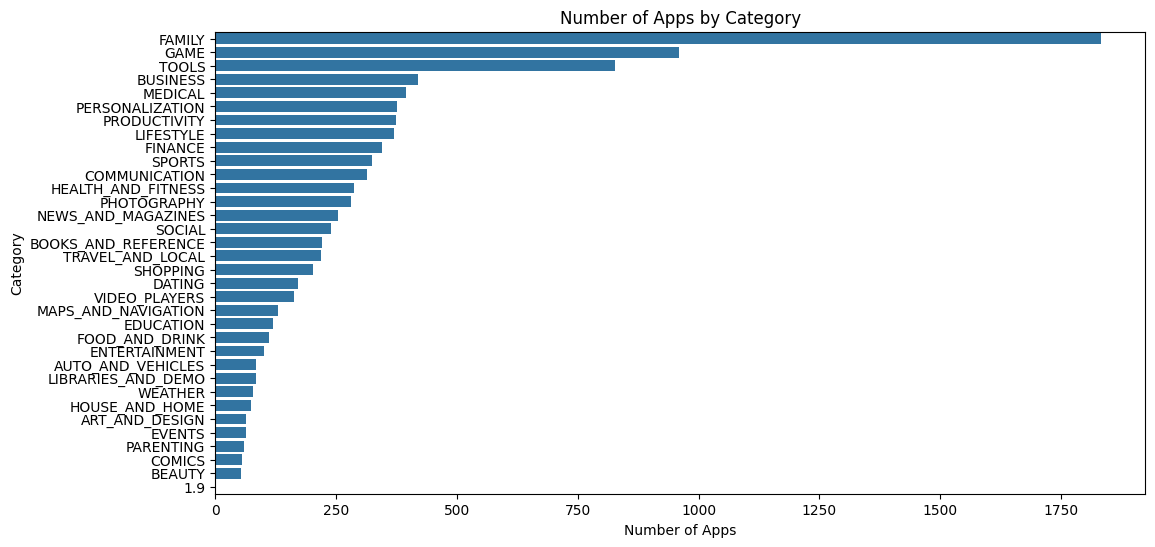

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title('Number of Apps by Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

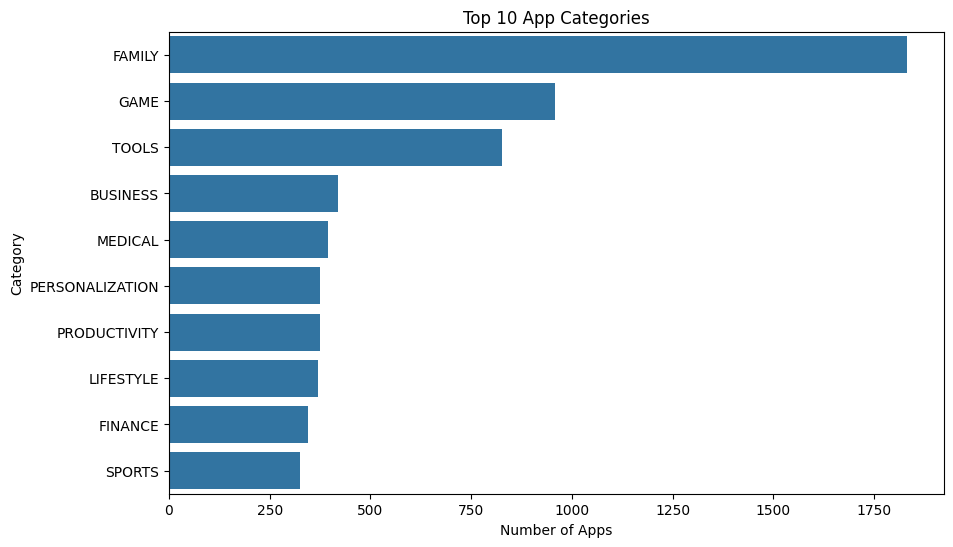

In [ ]:
top_categories = category_counts.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top 10 App Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

###**Ratings Analysis**

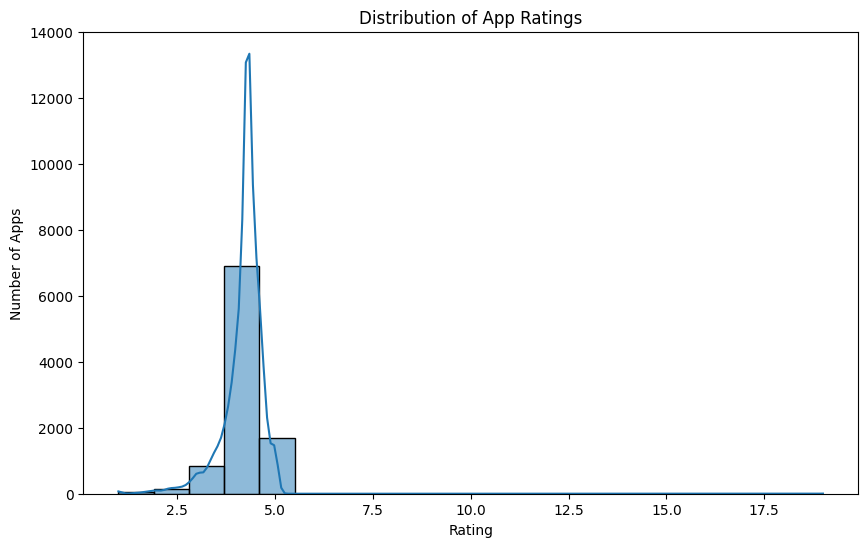

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(apps['Rating'], bins=20, kde=True)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.show()

In [ ]:
avg_rating_category = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

avg_rating_category

,Rating
Category,
1.9,19.000000
EVENTS,4.395313
EDUCATION,4.363866
ART_AND_DESIGN,4.354687
BOOKS_AND_REFERENCE,4.334234
PERSONALIZATION,4.325532
PARENTING,4.300000
BEAUTY,4.283019
SOCIAL,4.255230


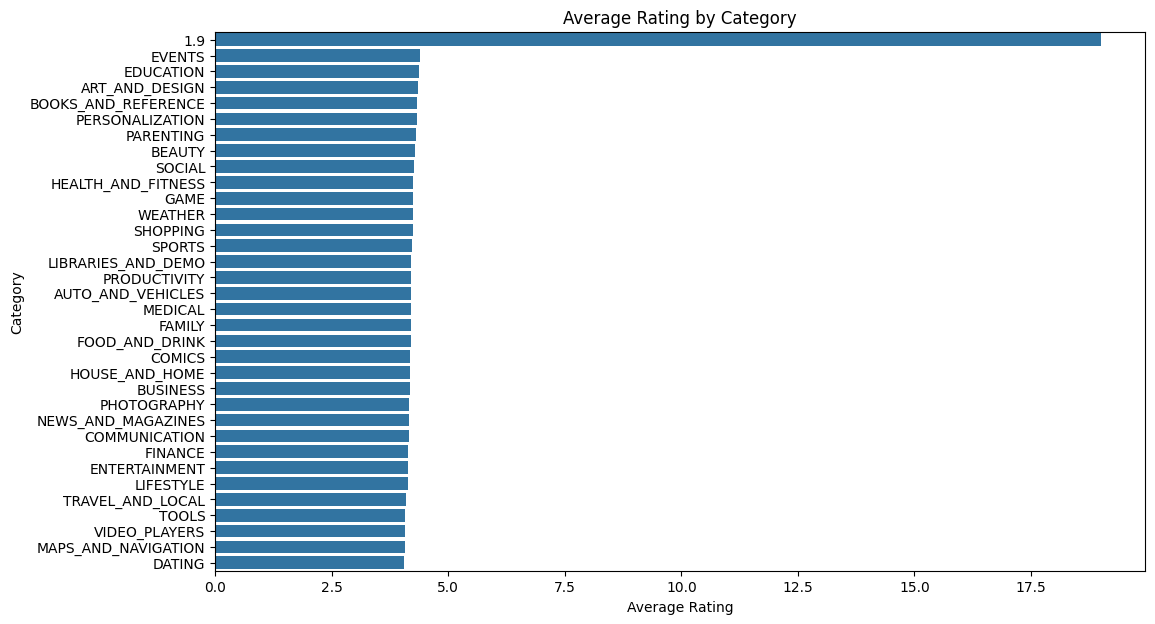

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index
)

plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

###**Size vs Installs**

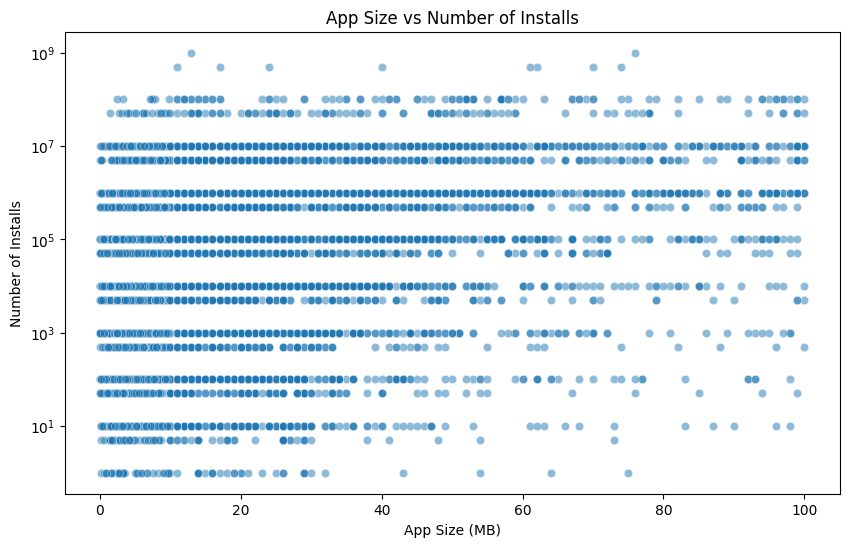

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x='Size_MB',
    y='Installs',
    alpha=0.5
)

plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')
plt.yscale('log')

plt.show()

In [ ]:
apps[['Size_MB', 'Installs']].corr()

,Size_MB,Installs
Size_MB,1.000000,0.134291
Installs,0.134291,1.000000


In [ ]:
apps['Size_MB'].corr(apps['Installs'])

np.float64(0.13429103526623293)

###**Pricing Analysis**

In [ ]:
apps['Type'].value_counts()

,count
Type,
Free,8902
Paid,756
Unknown,1
0,1


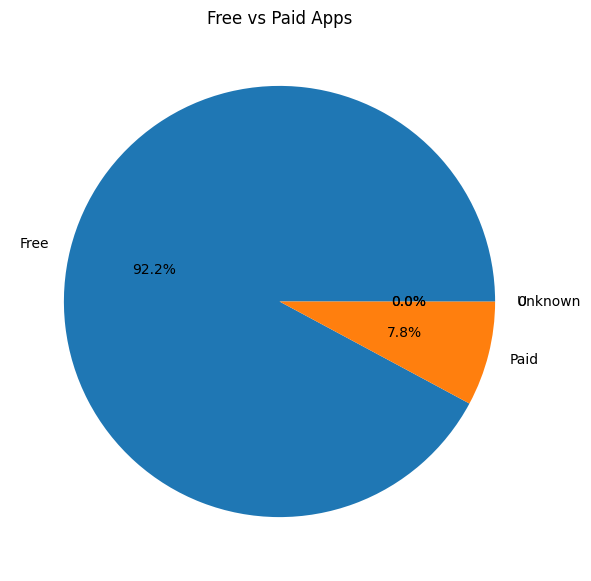

In [ ]:
type_counts = apps['Type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)

plt.title('Free vs Paid Apps')
plt.show()

In [ ]:
paid_apps = apps[apps['Type'] == 'Paid'].copy()

paid_apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442.0,6.8M,100000.0,Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up,6.8
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295.0,39M,100000.0,Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up,39.0
427,Puffin Browser Pro,COMMUNICATION,4.0,18247.0,Varies with device,100000.0,Paid,3.99,Everyone,Communication,"July 5, 2018",7.5.3.20547,4.1 and up,NaN
476,"Moco+ - Chat, Meet People",DATING,4.2,1545.0,Varies with device,10000.0,Paid,3.99,Mature 17+,Dating,"June 19, 2018",2.6.139,4.1 and up,NaN
477,Calculator,DATING,2.6,57.0,6.2M,1000.0,Paid,6.99,Everyone,Dating,"October 25, 2017",1.1.6,4.0 and up,6.2


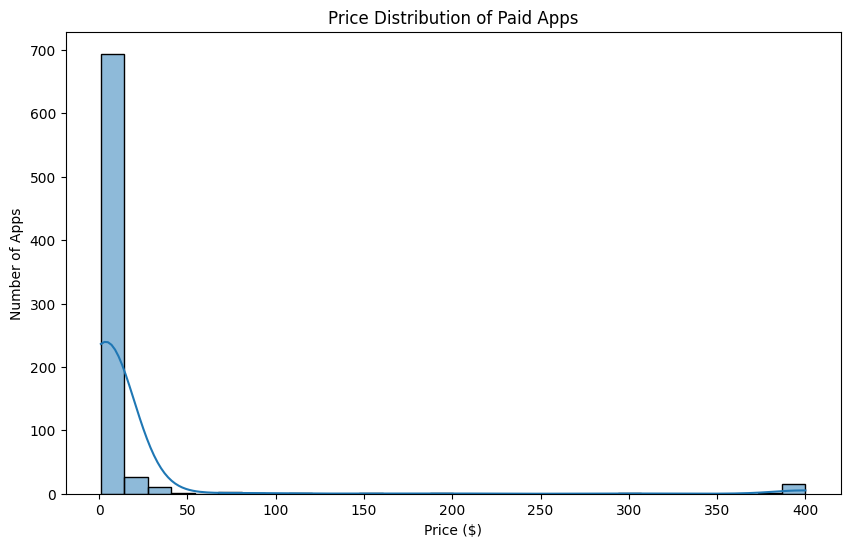

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(paid_apps['Price'], bins=30, kde=True)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

###**Revenue Estimation**

In [ ]:
apps['Estimated_Revenue'] = apps['Installs'] * apps['Price']

In [ ]:
revenue_by_category = (
    apps.groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.head(10)

,Estimated_Revenue
Category,
FAMILY,1.136798e+08
LIFESTYLE,5.758394e+07
GAME,4.068864e+07
FINANCE,2.572668e+07
PHOTOGRAPHY,8.547768e+06
PERSONALIZATION,6.796948e+06
MEDICAL,5.957536e+06
TOOLS,5.464821e+06
SPORTS,4.706212e+06


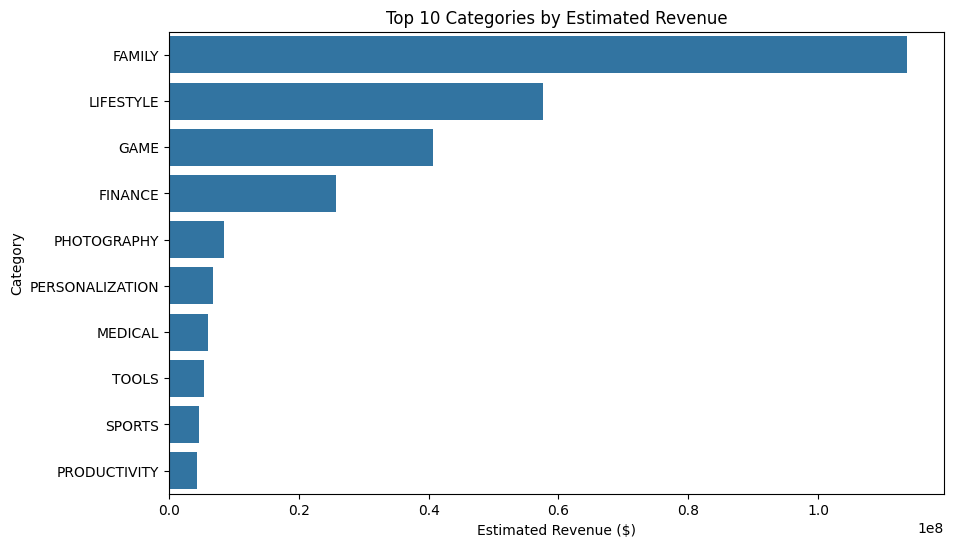

In [ ]:
top_revenue = revenue_by_category.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_revenue.values,
    y=top_revenue.index
)

plt.title('Top 10 Categories by Estimated Revenue')
plt.xlabel('Estimated Revenue ($)')
plt.ylabel('Category')

plt.show()

###**Explore User Reviews**

In [ ]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
reviews.shape

(64295, 5)

In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
reviews.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [ ]:
reviews.duplicated().sum()

np.int64(33616)

In [ ]:
reviews = reviews.dropna(subset=['Translated_Review'])

In [ ]:
reviews.shape

(37427, 5)

###**Sentiment Analysis**

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
reviews['Sentiment'] = reviews['Translated_Review'].apply(get_sentiment)

In [ ]:
reviews[['Translated_Review', 'Sentiment']].head(10)

,Translated_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
3,Works great especially going grocery store,Positive
4,Best idea us,Positive
5,Best way,Positive
6,Amazing,Positive
8,"Looking forward app,",Neutral
9,It helpful site ! It help foods get !,Neutral
10,good you.,Positive
11,Useful information The amount spelling errors ...,Positive


###**Sentiment Distribution**

In [ ]:
sentiment_counts = reviews['Sentiment'].value_counts()

sentiment_counts

,count
Sentiment,
Positive,23997
Negative,8272
Neutral,5158


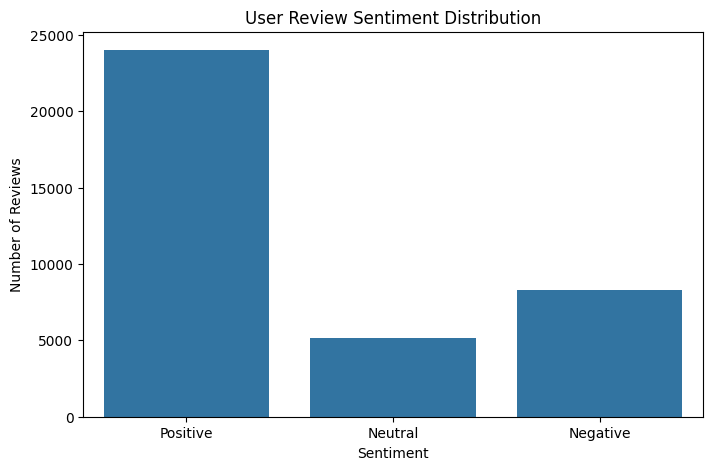

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x='Sentiment'
)

plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

###**Sentiment by Category**

In [ ]:
reviews_category = reviews.merge(
    apps[['App', 'Category']],
    on='App',
    how='left'
)
reviews_category.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best way,Positive,1.00,0.300000,HEALTH_AND_FITNESS


In [ ]:
sentiment_category = pd.crosstab(
    reviews_category['Category'],
    reviews_category['Sentiment']
)

sentiment_category.head()

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,61,62,259
AUTO_AND_VEHICLES,17,36,236
BEAUTY,65,88,185
BOOKS_AND_REFERENCE,95,108,448
BUSINESS,169,258,655


In [ ]:
positive_categories = (
    sentiment_category['Positive']
    .sort_values(ascending=False)
    .head(10)
)

positive_categories

,Positive
Category,
GAME,3936
HEALTH_AND_FITNESS,1754
FAMILY,1249
DATING,1068
TRAVEL_AND_LOCAL,1034
PRODUCTIVITY,990
MEDICAL,967
SPORTS,938
FINANCE,911


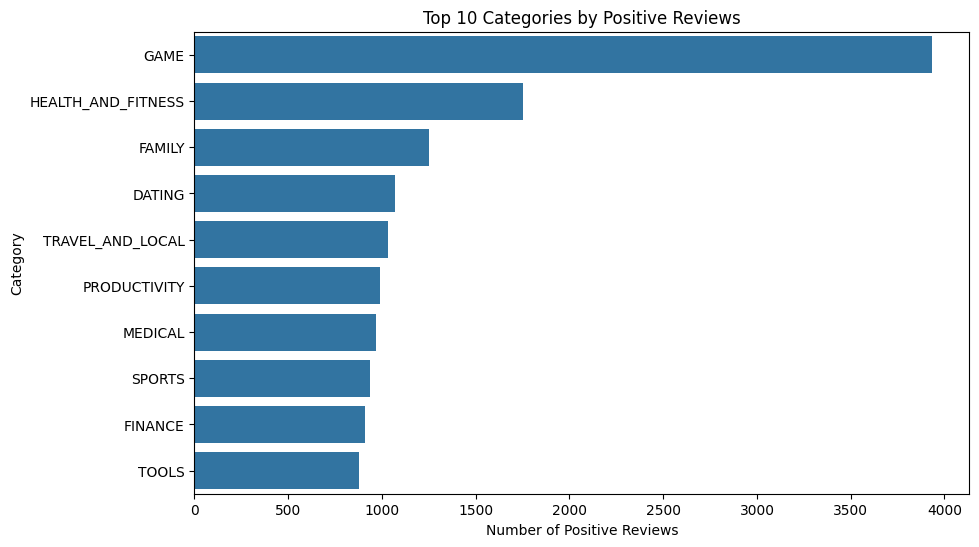

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=positive_categories.values,
    y=positive_categories.index
)

plt.title('Top 10 Categories by Positive Reviews')
plt.xlabel('Number of Positive Reviews')
plt.ylabel('Category')

plt.show()

In [ ]:
negative_categories = (
    sentiment_category['Negative']
    .sort_values(ascending=False)
    .head(10)
)

negative_categories

,Negative
Category,
GAME,2408
FAMILY,552
TRAVEL_AND_LOCAL,367
DATING,361
SPORTS,337
FINANCE,320
ENTERTAINMENT,319
NEWS_AND_MAGAZINES,276
PRODUCTIVITY,269


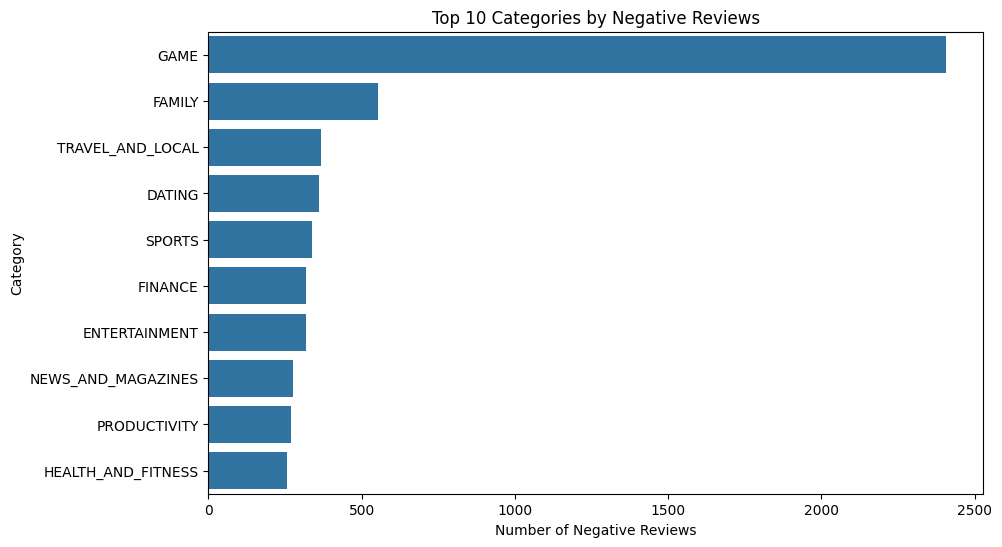

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=negative_categories.values,
    y=negative_categories.index
)

plt.title('Top 10 Categories by Negative Reviews')
plt.xlabel('Number of Negative Reviews')
plt.ylabel('Category')

plt.show()

###**Interactive Plotly Visualization**

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

In [ ]:
category_df = (
    apps['Category']
    .value_counts()
    .reset_index()
)

category_df.columns = ['Category', 'App_Count']

In [ ]:
fig = px.bar(
    category_df,
    x='Category',
    y='App_Count',
    title='Interactive App Distribution by Category',
    hover_data=['App_Count']
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [ ]:
apps[['App', 'Category', 'Installs']].sort_values(
    'Installs',
    ascending=False
).head(10)

,App,Category,Installs
3736,Google News,NEWS_AND_MAGAZINES,1.000000e+09
2554,Google+,SOCIAL,1.000000e+09
1654,Subway Surfers,GAME,1.000000e+09
152,Google Play Books,BOOKS_AND_REFERENCE,1.000000e+09
3665,YouTube,VIDEO_PLAYERS,1.000000e+09
2545,Instagram,SOCIAL,1.000000e+09
3687,Google Play Movies & TV,VIDEO_PLAYERS,1.000000e+09
2808,Google Photos,PHOTOGRAPHY,1.000000e+09
3127,Google Street View,TRAVEL_AND_LOCAL,1.000000e+09
865,Google Play Games,ENTERTAINMENT,1.000000e+09


In [ ]:
apps[['App', 'Category', 'Reviews']].sort_values(
    'Reviews',
    ascending=False
).head(10)

,App,Category,Reviews
2544,Facebook,SOCIAL,78158306.0
336,WhatsApp Messenger,COMMUNICATION,69119316.0
2545,Instagram,SOCIAL,66577313.0
335,Messenger – Text and Video Chat for Free,COMMUNICATION,56642847.0
1670,Clash of Clans,GAME,44891723.0
4005,Clean Master- Space Cleaner & Antivirus,TOOLS,42916526.0
1654,Subway Surfers,GAME,27722264.0
3665,YouTube,VIDEO_PLAYERS,25655305.0
7536,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,24900999.0
1660,Clash Royale,GAME,23133508.0


In [ ]:
apps[['App', 'Category', 'Rating']].sort_values(
    'Rating',
    ascending=False
).head(10)

,App,Category,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0
5776,Food-Aw - Order Food Online in Aruba,FOOD_AND_DRINK,5.0
5763,Tozer Devotional -Series 1,BOOKS_AND_REFERENCE,5.0
7377,CI 174 Gray Icon Pack,PERSONALIZATION,5.0
9512,Hum Ek Hain 2.02,SOCIAL,5.0
9511,Ek Bander Ne Kholi Dukan,FAMILY,5.0
8234,DB Pickles,BUSINESS,5.0
7405,Nur təfsiri 1-ci cild,LIBRARIES_AND_DEMO,5.0
9518,Asha Ek Hope - ALS/ MND,MEDICAL,5.0
9517,Ek Vote,PRODUCTIVITY,5.0


###**Data Quality Check**

In [ ]:
print("Final dataset shape:", apps.shape)
print("Duplicate apps:", apps['App'].duplicated().sum())
print("Missing ratings:", apps['Rating'].isnull().sum())
print("Missing installs:", apps['Installs'].isnull().sum())
print("Missing prices:", apps['Price'].isnull().sum())

Final dataset shape: (9660, 15)
Duplicate apps: 0
Missing ratings: 0
Missing installs: 1
Missing prices: 1


In [ ]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Estimated_Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8,0.0


##**Conclusion**

We looked at the Google Play Store dataset to learn about how appsre shared how they are rated how many people install them how much they cost how big they are, how much money they might make and what people think.

The analysis revealed that some app categories have more apps than other categories meaning those categories are crowded and competitive. Ratings were mostly on the side but the average rating varied from one category to another.

We looked at app size. How many people install them to see if bigger apps get more or fewer installs. Pricing analysis showed that free apps dominate the Google Play Store while paid apps make up a small part of the data. Estimated revenue analysis gave an idea of how much money paid apps could make, based on how many people install them and their listed prices.

User reviews were examined with TextBlob sentiment analysis and sorted into Positive, Negative and Neutral categories. This helped us see how users normally feel about apps and which categories get positive or negative feedback.

Key Insights

Free apps dominate the Play Store showing that developers often rely on distribution to reach more people.

App categories differ a lot in how apps they contain and how competitive they are with some categories having many more apps, than others.

User sentiment gives feedback for developers because positive and negative reviews can show what users like and what needs improvement.